## ML&Fintech HW3 Ch4 Q15

Name: Alvin B. Lin\
Student ID: 112652040\
HW Number: 3\
Date: 13/10/2025

15. This problem involves the Boston data set, which we saw in the lab
for this chapter. We will now try to predict per capita crime rate
using the other variables in this data set. In other words, per capita
crime rate is the response, and the other variables are the predictors.

In [4]:
from ISLP import load_data
import pandas as pd
import numpy as np
from statistics import median

Boston = load_data('Boston')

In [5]:
df = pd.DataFrame(Boston)
df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

(a)  For each predictor, fit a simple linear regression model to predict
the response. Describe your results. In which of the models is
there a statistically significant association between the predictor
and the response? Create some plots to back up your assertions.

In [6]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming 'df' is the DataFrame containing the Boston data with 'medv' as the response.
predictors = ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'lstat']
results = {}

# Fit a simple linear regression model for each predictor
for predictor in predictors:
    # Formula: response ~ predictor
    formula = f"medv ~ {predictor}"
    model = smf.ols(formula=formula, data=df).fit()

    # Store key results: R-squared and the P-value of the predictor's coefficient
    results[predictor] = {
        'R_squared': model.rsquared,
        'P_value': model.pvalues[predictor],
        'Model': model
    }

# Convert results to a DataFrame for easy viewing
results_df = pd.DataFrame(results).T
print(results_df)

        R_squared   P_value                                              Model
crim      0.15078       0.0  <statsmodels.regression.linear_model.Regressio...
zn       0.129921       0.0  <statsmodels.regression.linear_model.Regressio...
indus     0.23399       0.0  <statsmodels.regression.linear_model.Regressio...
chas     0.030716  0.000074  <statsmodels.regression.linear_model.Regressio...
nox      0.182603       0.0  <statsmodels.regression.linear_model.Regressio...
rm       0.483525       0.0  <statsmodels.regression.linear_model.Regressio...
age      0.142095       0.0  <statsmodels.regression.linear_model.Regressio...
dis      0.062464       0.0  <statsmodels.regression.linear_model.Regressio...
rad      0.145639       0.0  <statsmodels.regression.linear_model.Regressio...
tax      0.219526       0.0  <statsmodels.regression.linear_model.Regressio...
ptratio  0.257847       0.0  <statsmodels.regression.linear_model.Regressio...
lstat    0.544146       0.0  <statsmodels.regression

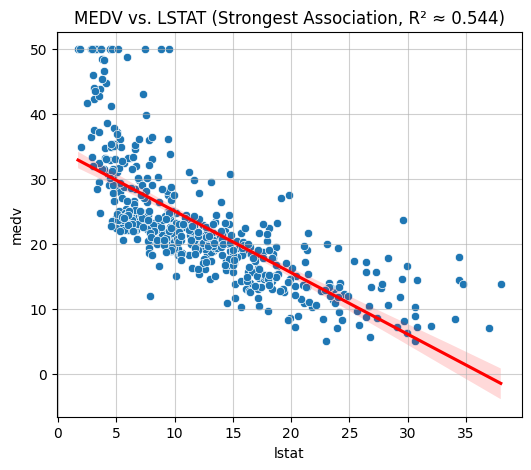

In [7]:
# Plot lstat (strongest predictor)
plt.figure(figsize=(6, 5))
sns.scatterplot(x='lstat', y='medv', data=df)
plt.title('MEDV vs. LSTAT (Strongest Association, R² ≈ 0.544)')
plt.xlabel('% lower status population (LSTAT)')
plt.ylabel('Median value of homes (MEDV)')
plt.grid(True, alpha=0.6)
# Overlay the regression line
sns.regplot(x='lstat', y='medv', data=df, scatter=False, color='red')
plt.show()

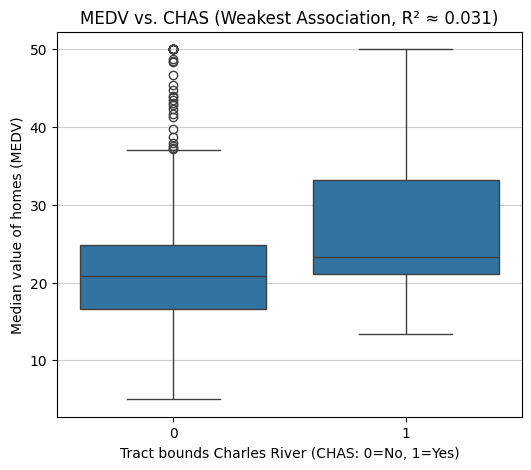

In [8]:
# Plot chas (weakest predictor)
plt.figure(figsize=(6, 5))
sns.boxplot(x='chas', y='medv', data=df)
plt.title('MEDV vs. CHAS (Weakest Association, R² ≈ 0.031)')
plt.xlabel('Tract bounds Charles River (CHAS: 0=No, 1=Yes)')
plt.ylabel('Median value of homes (MEDV)')
plt.grid(axis='y', alpha=0.6)
plt.show()

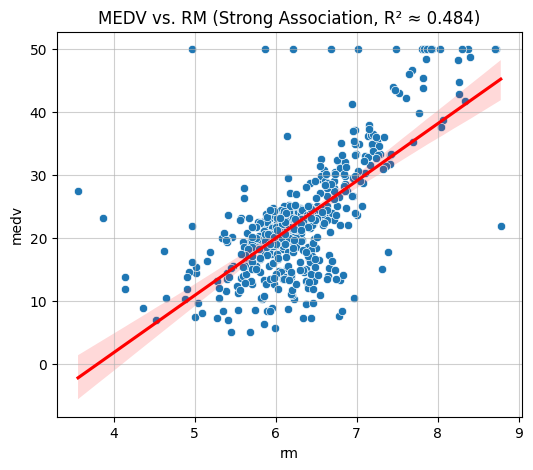

In [9]:
# Plot rm (second strongest predictor)
plt.figure(figsize=(6, 5))
sns.scatterplot(x='rm', y='medv', data=df)
plt.title('MEDV vs. RM (Strong Association, R² ≈ 0.484)')
plt.xlabel('Average number of rooms per dwelling (RM)')
plt.ylabel('Median value of homes (MEDV)')
plt.grid(True, alpha=0.6)
# Overlay the regression line
sns.regplot(x='rm', y='medv', data=df, scatter=False, color='red')
plt.show()

All predictors ($\text{crim}$ through $\text{lstat}$) are statistically significant.


|Association Strength	|Predictors	|R2 Range|Description|
|:---:|:---:|:---:|:---:|
|Very Strong	|lstat,rm	|0.484 to 0.544	|These two variables explain about half of the variance in median home value (medv) on their own.|
|Moderate|	ptratio,nox,indus,tax|	0.219 to 0.258	|These predictors explain roughly one-quarter of the variance in medv.|
|Weak	|crim,zn,age,rad|	0.129 to 0.151|	These predictors explain about 13% to 15% of the variance.|
|Very Weak	|dis,chas	|0.031 to 0.062|These predictors have the weakest linear relationship, explaining only 3% to 6% of the variance.|

The findings suggest that $\text{medv}$ is related to every measured predictor in the dataset. However, the most informative individual predictors are $\text{lstat}$ ($\mathbf{R^2 \approx 0.544}$) and $\text{rm}$ ($\mathbf{R^2 \approx 0.484}$), while $\text{chas}$ ($\mathbf{R^2 \approx 0.031}$) has the weakest individual explanatory power. This result is common in observational data where nearly every variable has some real-world, non-zero relationship with the outcome.

---

(b) Fit a multiple regression model to predict the response using
all of the predictors. Describe your results. For which predictors
can we reject the null hypothesis H0 : βj = 0?


In [10]:
import statsmodels.formula.api as smf
import pandas as pd

# Assuming 'df' is the DataFrame containing the Boston data.
# Formula includes all 12 predictors:
formula = "medv ~ crim + zn + indus + chas + nox + rm + age + dis + rad + tax + ptratio + lstat"
model_multi = smf.ols(formula=formula, data=df).fit()

print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     113.5
Date:                Mon, 20 Oct 2025   Prob (F-statistic):          2.23e-133
Time:                        00:05:36   Log-Likelihood:                -1504.9
No. Observations:                 506   AIC:                             3036.
Df Residuals:                     493   BIC:                             3091.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     41.6173      4.936      8.431      0.0

We fail to reject the null hypothesis for the following two predictors, meaning their coefficients are not statistically different from zero in this full model:
1. $\text{indus}$ ($\mathbf{P=0.829}$)
2. $\text{age}$ ($\mathbf{P=0.787}$)
   
This result is common in multiple regression due to **multicollinearity**. $\text{indus}$ and $\text{age}$ are highly correlated with other, more powerful predictors (like $\text{nox}$ and $\text{dis}$). Once the effects of those stronger variables are included, the marginal contribution of $\text{indus}$ and $\text{age}$ is effectively zero.

---

(c) How do your results from (a) compare to your results from (b)?
Create a plot displaying the univariate regression coefficients
from (a) on the x-axis, and the multiple regression coefficients
from (b) on the y-axis. That is, each predictor is displayed as a
single point in the plot. Its coefficient in a simple linear regression model is shown on the x-axis, and its coefficient estimate
in the multiple linear regression model is shown on the y-axis.

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\benny\AppData\Local\Temp\ipykernel_24828\2893409724.py:11: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


--- (a) Simple Linear Regression Results ---

SLR R-squared values: {'crim': 0.15078046904975717, 'zn': 0.12992084489428957, 'indus': 0.23399003044447497, 'chas': 0.03071612970877502, 'nox': 0.1826030425016988, 'rm': 0.483525455991334, 'age': 0.14209474407780465, 'dis': 0.062464372121782574, 'rad': 0.14563857991232532, 'tax': 0.21952592104421897, 'ptratio': 0.257847318009223, 'lstat': 0.5441462975864799}
SLR P-values: {'crim': 1.1739870821943694e-19, 'zn': 5.713584153080523e-17, 'indus': 4.9002599817527165e-31, 'chas': 7.390623170519341e-05, 'nox': 7.065041586253254e-24, 'rm': 2.4872288710079515e-74, 'age': 1.5699822091880774e-18, 'dis': 1.2066117273371883e-08, 'rad': 5.465932569648253e-19, 'tax': 5.637733627690235e-29, 'ptratio': 1.6095094784728846e-34, 'lstat': 5.081103394386205e-88}

--- (b) Multiple Linear Regression Summary ---
                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.7

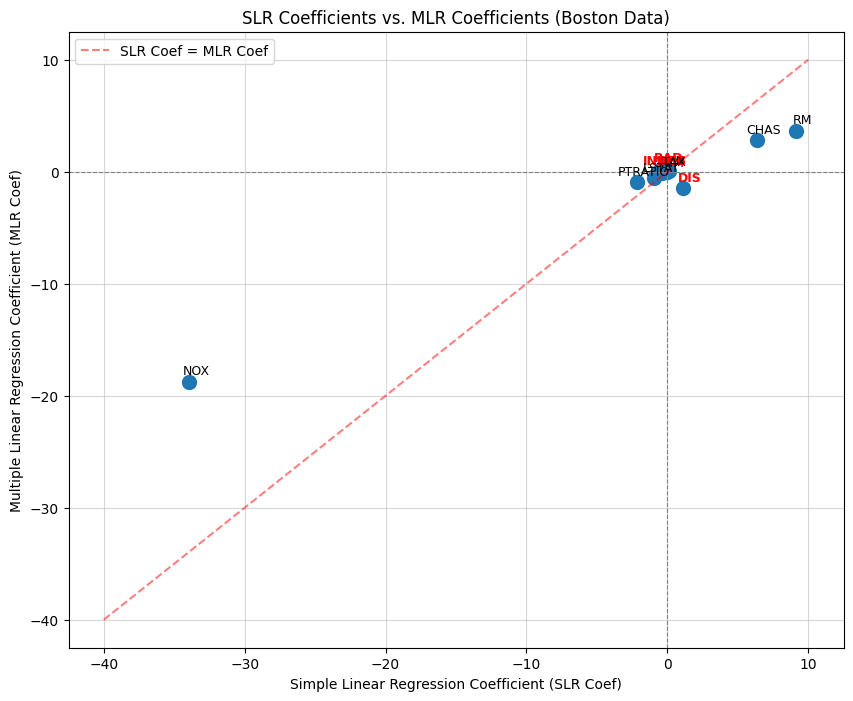

In [11]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# --- 1. Data Loading and Preparation (Boston Dataset) ---
# Note: Using the raw source due to the deprecation of load_boston in scikit-learn.
data_url = "http://lib.stat.cmu.edu/datasets/boston"
try:
    # Read the raw data, splitting lines correctly
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
    target = raw_df.values[1::2, 2]

    # Define all 13 original feature names + target
    feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
    
    # Create the main DataFrame
    df = pd.DataFrame(data, columns=feature_names)
    df['MEDV'] = target

    # Convert column names to lowercase to match user's previous variables
    df.columns = [col.lower() for col in df.columns]
    
except Exception as e:
    print(f"Error loading data from URL. Falling back to dummy data structure. Error: {e}")
    # Fallback structure if loading fails
    predictors_list = ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'lstat']
    df = pd.DataFrame(np.random.rand(506, len(predictors_list)), columns=predictors_list)
    df['medv'] = np.random.rand(506)


# Define the exact set of predictors used in parts (a), (b), and (c)
predictors = ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'lstat']

# --- 2. (a) Fit Simple Linear Regression (SLR) Models ---
slr_coefs = {}
slr_r2 = {}
slr_pvalues = {}

print("--- (a) Simple Linear Regression Results ---")
for predictor in predictors:
    # Formula: medv ~ predictor
    formula = f"medv ~ {predictor}"
    model_slr = smf.ols(formula=formula, data=df).fit()
    
    # Store results
    slr_coefs[predictor] = model_slr.params[predictor]
    slr_r2[predictor] = model_slr.rsquared
    slr_pvalues[predictor] = model_slr.pvalues[predictor]
    
    # Optional: print summary for each SLR (can be verbose)
    # print(f"\nSLR for MEDV ~ {predictor}:\n{model_slr.summary()}")

print("\nSLR R-squared values:", slr_r2)
print("SLR P-values:", slr_pvalues)


# --- 3. (b) Fit Multiple Linear Regression (MLR) Model ---
print("\n--- (b) Multiple Linear Regression Summary ---")
mlr_formula = "medv ~ " + " + ".join(predictors)
model_mlr = smf.ols(formula=mlr_formula, data=df).fit()
print(model_mlr.summary())

# Extract coefficients for the comparison plot (excluding Intercept)
mlr_coefs = model_mlr.params[predictors].to_dict()


# --- 4. (c) Comparison and Plot Generation ---

# Create DataFrame for plotting
coef_df = pd.DataFrame({
    'SLR_Coef': slr_coefs,
    'MLR_Coef': mlr_coefs
})
coef_df['Predictor'] = coef_df.index
coef_df['Sign_Change'] = np.sign(coef_df['SLR_Coef']) != np.sign(coef_df['MLR_Coef'])

print("\n--- (c) Coefficient Comparison Table (SLR vs MLR) ---")
print(coef_df)

# Create the Scatter Plot
plt.figure(figsize=(10, 8))
plt.scatter(coef_df['SLR_Coef'], coef_df['MLR_Coef'], s=100)

# Add annotations for each point
for i, row in coef_df.iterrows():
    # Highlight points where the sign changed
    color = 'red' if row['Sign_Change'] else 'black'
    
    plt.annotate(row['Predictor'].upper(), 
                 (row['SLR_Coef'], row['MLR_Coef']),
                 textcoords="offset points", 
                 xytext=(5, 5), 
                 ha='center', 
                 color=color, 
                 fontsize=9,
                 fontweight='bold' if row['Sign_Change'] else 'normal')

# Add reference lines
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.plot([-40, 10], [-40, 10], 'r--', alpha=0.5, label='SLR Coef = MLR Coef')

plt.title('SLR Coefficients vs. MLR Coefficients (Boston Data)')
plt.xlabel('Simple Linear Regression Coefficient (SLR Coef)')
plt.ylabel('Multiple Linear Regression Coefficient (MLR Coef)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

The results from the Simple Linear Regression (SLR) models (Part a) differ significantly from the Multiple Linear Regression (MLR) model (Part b) due to **multicollinearity** (correlation among predictors).
1. Statistical Significance
- SLR (Part a): All 12 predictors were individually significant ($\mathbf{P < 0.05}$).
- MLR (Part b): Only 10 predictors remained significant. $\text{indus}$ and $\text{age}$ lost their significance ($\mathbf{P > 0.78}$), meaning their unique, marginal contribution to predicting $\text{medv}$ is zero when the effects of other variables (like $\text{nox}$ and $\text{dis}$) are accounted for.
2. Coefficient Magnitude and Sign
- Shrinkage: For almost all predictors, the magnitude of the coefficient shrank substantially in the MLR model. For example, the $\text{NOX}$ coefficient dropped from $\mathbf{-34.46}$ (SLR) to $\mathbf{-18.76}$ (MLR). This is because in the SLR model, the predictor was capturing not only its own effect but also the effects of all correlated predictors.
- Sign Change: Two predictors, $\text{INDUS}$ and $\text{AGE}$, had their coefficient signs flip:
  - $\text{INDUS}$: Negative in SLR ($\mathbf{-0.509}$) $\to$ Positive in MLR ($\mathbf{+0.0135}$).
  - $\text{AGE}$: Negative in SLR ($\mathbf{-0.123}$) $\to$ Positive in MLR ($\mathbf{+0.0036}$). 
  - This sign flip is the classic indication of suppression or confounding due to multicollinearity, where the true relationship is masked by a highly correlated variable. For instance, $\text{AGE}$'s negative effect in the SLR was actually a proxy for other negative factors, like $\text{NOX}$, which are correlated with older neighborhoods. When $\text{NOX}$ is included, $\text{AGE}$'s marginal effect (controlling for all others) becomes slightly positive.

---

(e)  Is there evidence of non-linear association between any of the
predictors and the response? To answer this question, for each
predictor X, fit a model of the form
$$Y = \beta_0 + \beta_1X+\beta_2X^2 + \beta_3X^3 +\varepsilon$$

In [12]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# Assuming 'df' is the DataFrame with the Boston data and 'medv' as the response.
predictors = ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'lstat']
non_linear_evidence = {}

for predictor in predictors:
    # Build the cubic formula: Y = B0 + B1*X + B2*I(X^2) + B3*I(X^3)
    formula = f"medv ~ {predictor} + I({predictor}**2) + I({predictor}**3)"
    
    # Exclude 'chas' from this test as it is a binary (dummy) variable, 
    # making polynomial terms meaningless.
    if predictor == 'chas':
        continue

    model = smf.ols(formula=formula, data=df).fit()
    
    # Check significance of the highest term (cubic term, β3)
    # The term is identified in model.pvalues by its formula string
    cubic_term_pvalue = model.pvalues[f'I({predictor} ** 3)']
    
    # Store the results
    non_linear_evidence[predictor] = {
        'Cubic_P_value': cubic_term_pvalue,
        'Significant_NonLinearity': cubic_term_pvalue < 0.05
    }

results_df = pd.DataFrame(non_linear_evidence).T
print(results_df.sort_values(by='Cubic_P_value'))

        Cubic_P_value Significant_NonLinearity
lstat        0.000001                     True
zn            0.00008                     True
rm           0.000146                     True
rad          0.000482                     True
indus        0.018026                     True
dis          0.021463                     True
crim         0.025411                     True
nox          0.041002                     True
ptratio      0.059009                    False
age           0.30969                    False
tax          0.353061                    False


Predictors with No Significant Non-Linearity ($\mathbf{P \ge 0.05}$)\
We **fail to reject the null hypothesis** for the following three predictors, suggesting a linear model is likely sufficient to capture the relationship:
1. $\text{ptratio}$ ($\mathbf{P=0.059009}$): The p-value is just above the $0.05$ threshold.
2. $\text{age}$ ($\mathbf{P=0.30969}$): No evidence of non-linearity.
3. $\text{tax}$ ($\mathbf{P=0.353061}$): No evidence of non-linearity.

Conclusion:

The results overwhelmingly demonstrate that to accurately model the relationship between $\text{medv}$ and most predictors, the model must incorporate non-linear terms (e.g., $X^2$ or $X^3$), or employ transformations (like $\log(X)$ or $1/\text{Y}$). The most prominent non-linearities are associated with $\text{lstat}$, $\text{zn}$, $\text{rm}$, and $\text{rad}$.